In [ ]:
import os
# manually specify the GPUs to use
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"
import sys
import torch
import tqdm 
import pickle as pkl
import numpy as np


module_path = os.path.abspath('..')
if module_path not in sys.path:
    sys.path.insert(0, module_path)

from torch.utils.data import DataLoader
from datasets import TransformerConf4Dataset, CNFDataset
from models import TransformerConf3, LightningModelCNF
from utils import args_transformer, args_cnf, create_mask_src, create_mask_tgt

from config import FitConfig
from model_loader import GlobalModelLoader
from run_fit import VertexFitter



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.multiprocessing.set_sharing_strategy('file_system')

cfg = FitConfig(
    data_term="KL_combined",
    lam_a = 1e-5,
    adam_lr = 1e-2,
    adam_steps = 200,
    background_mode="none",

    n_sample_for_template=200,
    n_fit_per_event=1,
    use_lbfgs=True,
    lbfgs_steps=50,
)


In [2]:
# set up the models
model_loader = GlobalModelLoader(device)
model_loader.load_models()





- Arguments:
  dataset_path: /pscratch/sd/b/botaoli/SFGD_VA/Data/NN_Data_compressed/{}/{}/{}/{}.zip
  metadata_path: /pscratch/sd/b/botaoli/SFGD_VA/Data/NN_Data_compressed/metadata.pkl
  event_in_folder: 100000
  seed: 42
  max_p: 5
  max_p_contained: 5
  max_p_exiting: 1
  mom_smearing_p: 0.07
  mom_smearing_mu: 0.07
  cube_size: 10.27
  va_size: 7
  pad_value: -10000
  hidden: 192
  dropout: 0.1
  encoder_layers: 10
  decoder_layers: 10
  attn_heads: 16
  batch_size: 16
  epochs: 12420
  num_workers: 32
  lr: 0.002
  accum_grad_batches: 4
  cosine_annealing_steps: 400
  weight_decay: 0.01
  beta1: 0.9
  beta2: 0.999
  eps: 1e-09
  warmup_steps: 20
  save_dir: logs
  name: v1
  log_every_n_steps: 50
  early_stop_patience: 0
  save_top_k: 1
  checkpoint_path: /pscratch/sd/b/botaoli/SFGD_VA/Results/checkpoints
  checkpoint_name: v3
  load_checkpoint: None
  gpus: [0]
  num_nodes: 1


/global/homes/b/botaoli/.conda/envs/env_nn/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Model weights loaded!


In [3]:
# for test
test_data = model_loader.load_sample_data(0)

Number of batches: 7813


  0%|          | 0/7813 [00:00<?, ?it/s]/global/homes/b/botaoli/.conda/envs/env_nn/lib/python3.11/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
  0%|          | 0/7813 [00:01<?, ?it/s]


In [4]:
print("proton_contained_ekin_mean: ", model_loader.generator_model["proton_contained"].metadata['statistics']['per_tree']['proton_contained']['true_iniekin']['mean'])
print("proton_contained_ekin_std: ", model_loader.generator_model["proton_contained"].metadata['statistics']['per_tree']['proton_contained']['true_iniekin']['std'])

proton_contained_ekin_mean:  38.85369349908855
proton_contained_ekin_std:  22.17926268532521


In [5]:
print("true_ekin: ", test_data["ekin_true"][0])
print("true_dir: ", test_data["dir_true"][0])
print("true_vtx: ", test_data["vtx_true"][0])
print("pred_ekin: ", test_data["ekin_pred"][0])
print("pred_dir: ", test_data["dir_pred"][0])
print("pred_vtx: ", test_data["vtx_pred"][0])
print("N_pred: ", test_data["N_pred"][0])
print("N_true: ", test_data["N_true"][0])



true_ekin:  [[ 1.1906271]
 [-0.8727242]
 [-1.1738924]
 [-1.4489642]]
true_dir:  [[-0.02747619  0.9966424  -0.0771303 ]
 [-0.29660094 -0.2181903  -0.9297424 ]
 [ 0.8608451  -0.49747765  0.10705991]
 [-0.69898605 -0.49889147 -0.51237273]]
true_vtx:  [ 0.02203437 -0.26305288 -0.25678235]
pred_ekin:  [[ 1.2905658]
 [-0.8051122]
 [-1.2052954]
 [-1.4421864]]
pred_dir:  [[ 0.01186951  0.98592377 -0.16677356]
 [ 0.00869393  0.17109387 -0.9852163 ]
 [ 0.09866239  0.42654133  0.8990708 ]
 [-0.7896698  -0.3323836   0.5156964 ]]
pred_vtx:  [-0.01668169 -0.19462861 -0.24201849]
N_pred:  4
N_true:  4


In [4]:
data = test_data["hits"][0]
#convert to a tensor
data = torch.tensor(data)
fitter = VertexFitter(model_loader, cfg)
#result = fitter.fit(data, 0)


In [ ]:
result = fitter.fit(test_data, 1)

/global/common/software/m5022/botaoli/SFGD_VA/Code/NeutrinoVertex-DL/vaFit/run_fit.py:38: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1758491028874/work/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.tensor(dataset['hits'][:n_events], device=self.cfg.device, dtype=self.cfg.dtype)


tensor(1., device='cuda:0')
exit_particle:  torch.Size([1, 8])


generated_voxels shape:  torch.Size([200, 125])
TrackGenerator generated_voxels shape:  torch.Size([1, 125])
exit_muon shape:  torch.Size([1, 125])
0.4152350425720215 GB peak for this call
tensor(0., device='cuda:0')
exit_particle:  torch.Size([1, 8])
generated_voxels shape:  torch.Size([200, 125])
TrackGenerator generated_voxels shape:  torch.Size([1, 125])
0.5417380332946777 GB peak for this call
generated_voxels shape:  torch.Size([800, 125])
TrackGenerator generated_voxels shape:  torch.Size([4, 125])
0.9904980659484863 GB peak for this call
weights shape:  torch.Size([4])
x_sum shape:  torch.Size([1, 125])
x shape:  torch.Size([1, 125])
d_loss:  tensor(9.3733, device='cuda:0', grad_fn=<MeanBackward0>)
dir:  tensor([[ 0.0119,  0.9859, -0.1668],
        [ 0.0087,  0.1711, -0.9852],
        [ 0.0987,  0.4265,  0.8991],
        [-0.7897, -0.3324,  0.5157]], device='cuda:0', grad_fn=<DivBackward0>)
ekin:  tensor([[ 1.2906],
        [-0.8051],
        [-1.2053],
        [-1.4421]], devi

In [8]:
pred_vtx = result['vtx_pred']
print(pred_vtx.shape)
print(pred_vtx.reshape(10, 20, 3))


torch.Size([200, 3])
tensor([[[-3.5581e-01, -3.0915e+00, -3.9728e+00],
         [-1.1537e-01, -2.8563e+00, -3.8205e+00],
         [-7.0139e-01, -3.1957e+00, -3.9807e+00],
         [ 9.0630e-02, -2.8868e+00, -3.7627e+00],
         [-6.9777e-03, -3.1165e+00, -3.8623e+00],
         [-5.8955e-02, -3.3701e+00, -3.7112e+00],
         [-2.7867e-01, -3.2650e+00, -3.5967e+00],
         [-4.8804e-01, -3.2268e+00, -3.9601e+00],
         [-1.8289e-01, -3.7436e+00, -3.9877e+00],
         [-1.3269e-01, -2.8767e+00, -3.7692e+00],
         [ 1.0014e-02, -2.9556e+00, -4.0850e+00],
         [-3.3472e-01, -3.0170e+00, -3.8622e+00],
         [ 1.0190e-02, -3.1864e+00, -3.8863e+00],
         [-1.7560e-01, -3.1041e+00, -3.9941e+00],
         [-2.5784e-01, -3.1297e+00, -3.8612e+00],
         [-1.4443e-01, -3.1551e+00, -3.8771e+00],
         [ 6.8884e-02, -3.4128e+00, -3.8013e+00],
         [-2.6752e-01, -3.0883e+00, -3.9433e+00],
         [-5.1991e-02, -3.1148e+00, -3.8584e+00],
         [-3.6199e-01, -2.576

In [ ]:
import matplotlib.pyplot as plt
def check_fit_result(result, n_event, n_fit, data_set, cube_size):
    device = result['ekin_pred'].device
    dtype = result['ekin_pred'].dtype
    N_pred = data_set['N_pred']
    
    ekin_pred_raw = np.array([np.sum(chunk, axis=0) for chunk in data_set['ekin_pred']])
    #dir_pred_raw = np.array([chunk for chunk in data_set['dir_pred']])    
    vtx_pred_raw = torch.cat([torch.tensor(chunk, device=device, dtype=dtype).unsqueeze(0) for chunk in data_set['vtx_pred']], dim=0)
    vtx_pred_raw = vtx_pred_raw*cube_size*1.5
    
    #dir_pred_raw = dir_pred_raw
    vtx_pred_raw = vtx_pred_raw.cpu().numpy()

    pred_vtx = result['vtx_pred'].detach()
    pred_ekin = result['ekin_pred'].detach()
    #pred_dir = result['dir_pred'].detach()
    true_vtx = torch.tensor([result['vtx_true'][i] for i in range(n_event)]).detach()
    true_ekin = np.array([np.sum(chunk, axis=0) for chunk in result['ekin_true']])
    #true_dir = test_data['dir_true']
    
    accum_ind = np.array([np.sum(N_pred[:i]) for i in range(n_event+1)]).astype(int)
    
    pred_vtx = pred_vtx.reshape(n_event, n_fit, 3).mean(dim=1).cpu().numpy()
    pred_ekin = np.array([np.sum(pred_ekin[accum_ind[i]:accum_ind[i+1]].cpu().numpy(), axis=0) for i in range(n_event)])
    
    #pred_dir = pred_dir.reshape(n_event, n_fit, 3).mean(dim=1).cpu().numpy()
    true_vtx = true_vtx.reshape(n_event, 3).cpu().numpy()
    #true_ekin = true_ekin.reshape(n_event).cpu().numpy()    
    #true_dir = true_dir.reshape(n_event, 3).cpu().numpy()
    
    vtx_pred_raw_x = vtx_pred_raw[:, 0]
    vtx_pred_raw_y = vtx_pred_raw[:, 1]
    vtx_pred_raw_z = vtx_pred_raw[:, 2]
    pred_vtx_x = pred_vtx[:, 0]
    pred_vtx_y = pred_vtx[:, 1]
    pred_vtx_z = pred_vtx[:, 2]
    true_vtx_x = true_vtx[:, 0]
    true_vtx_y = true_vtx[:, 1]
    true_vtx_z = true_vtx[:, 2]
    
    # calculate the relative difference in three coordinate of vtx_pred and vtx_true
    vtx_rel_diff_before_x = (vtx_pred_raw_x - true_vtx_x)
    vtx_rel_diff_before_y = (vtx_pred_raw_y - true_vtx_y)
    vtx_rel_diff_before_z = (vtx_pred_raw_z - true_vtx_z)
    
    vtx_rel_diff_after_x = (pred_vtx_x - true_vtx_x)
    vtx_rel_diff_after_y = (pred_vtx_y - true_vtx_y)
    vtx_rel_diff_after_z = (pred_vtx_z - true_vtx_z)

    ekin_rel_diff_before = np.abs(ekin_pred_raw - true_ekin) / true_ekin
    ekin_rel_diff_after = np.abs(pred_ekin - true_ekin) / true_ekin

    
    # calculate the relative difference in ekin_pred and ekin_true
    # sort first 
    #total_ekin_raw = ekin_pred_raw.sum(axis=1)
    #total_ekin = pred_ekin.sum(axis=1)
    #total_ekin_true = true_ekin.sum(axis=1)
    #ekin_rel_diff_before = np.abs(total_ekin_raw - total_ekin_true) / total_ekin_true
    #ekin_rel_diff_after = np.abs(total_ekin - total_ekin_true) / total_ekin_true
    
    print("mean of vtx_rel_diff_before_x: ", vtx_rel_diff_before_x.mean())
    print("mean of vtx_rel_diff_after_x: ", vtx_rel_diff_after_x.mean())
    print("std of vtx_rel_diff_before_x: ", vtx_rel_diff_before_x.std())
    print("std of vtx_rel_diff_after_x: ", vtx_rel_diff_after_x.std())
    print("mean of vtx_rel_diff_before_y: ", vtx_rel_diff_before_y.mean())
    print("mean of vtx_rel_diff_after_y: ", vtx_rel_diff_after_y.mean())
    print("std of vtx_rel_diff_before_y: ", vtx_rel_diff_before_y.std())
    print("std of vtx_rel_diff_after_y: ", vtx_rel_diff_after_y.std())
    print("mean of vtx_rel_diff_before_z: ", vtx_rel_diff_before_z.mean())
    print("mean of vtx_rel_diff_after_z: ", vtx_rel_diff_after_z.mean())
    print("std of vtx_rel_diff_before_z: ", vtx_rel_diff_before_z.std())
    print("std of vtx_rel_diff_after_z: ", vtx_rel_diff_after_z.std())

    print("ekin_rel_diff_before_mean: ", ekin_rel_diff_before.mean())
    print("ekin_rel_diff_after_mean: ", ekin_rel_diff_after.mean())
    print("ekin_rel_diff_before_std: ", ekin_rel_diff_before.std())
    print("ekin_rel_diff_after_std: ", ekin_rel_diff_after.std())
    print("ekin_true: ", true_ekin)
    print("ekin_pred_raw: ", ekin_pred_raw)
    print("ekin_pred: ", pred_ekin)
    
    # draw box plot for vtx_rel_diff_before, vtx_rel_diff_after, ekin_rel_diff_before, ekin_rel_diff_after
    plt.figure(figsize=(10, 5))
    #plt.boxplot([vtx_rel_diff_before, vtx_rel_diff_after, ekin_rel_diff_before, ekin_rel_diff_after])
    plt.boxplot([vtx_rel_diff_before_x, vtx_rel_diff_after_x, vtx_rel_diff_before_y, vtx_rel_diff_after_y, vtx_rel_diff_before_z, vtx_rel_diff_after_z])
    plt.xticks([1, 2, 3, 4, 5, 6], ['vtx_rel_diff_before_x', 'vtx_rel_diff_after_x', 'vtx_rel_diff_before_y', 'vtx_rel_diff_after_y', 'vtx_rel_diff_before_z', 'vtx_rel_diff_after_z'])
    plt.show()
    
    
    
    
    
    
    


In [84]:
# save the results in a output file
with open('output.pkl', 'wb') as f:
    pkl.dump(result, f)


In [17]:
dataset = {k: v[:10] for k, v in test_data.items()}

mean of vtx_rel_diff_before_x:  -0.101500474
mean of vtx_rel_diff_after_x:  -0.16554777
std of vtx_rel_diff_before_x:  0.46205285
std of vtx_rel_diff_after_x:  1.1080049
mean of vtx_rel_diff_before_y:  0.11831738
mean of vtx_rel_diff_after_y:  -0.20052719
std of vtx_rel_diff_before_y:  0.4182048
std of vtx_rel_diff_after_y:  0.50774777
mean of vtx_rel_diff_before_z:  0.12290905
mean of vtx_rel_diff_after_z:  0.46683303
std of vtx_rel_diff_before_z:  0.15057951
std of vtx_rel_diff_after_z:  0.8866013
ekin_rel_diff_before_mean:  0.9958405694933067
ekin_rel_diff_after_mean:  0.3656775602476975
ekin_rel_diff_before_std:  0.011402634037259564
ekin_rel_diff_after_std:  0.20474310294274256
ekin_true:  [[104.29260053]
 [ 95.67645218]
 [135.23400808]
 [263.73107792]
 [156.83447178]
 [197.95764134]
 [127.47632059]
 [127.26916582]
 [125.32647583]
 [160.6123645 ]]
ekin_pred_raw:  [[-2.162028  ]
 [ 0.8386614 ]
 [ 0.39435667]
 [ 2.8987956 ]
 [ 0.05027771]
 [ 3.3534973 ]
 [ 0.62225866]
 [-1.3747971 ]

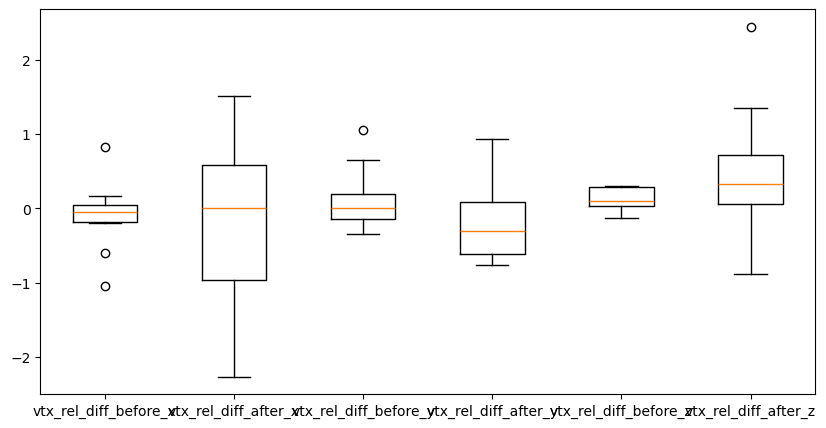

In [116]:
cube_size = model_loader.test_dataset.cube_size
check_fit_result(result, 10, 20, dataset, cube_size)

In [ ]:
print(test_data.keys())

In [ ]:
print(test_data['exit_particle'])

